<a href="https://colab.research.google.com/github/NAGASRISARANYA-1617/TITANIC-SURVIVAL-PREDICTION/blob/main/TITANIC_SURVIVAL_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORT LIBRARIES


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [27]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (4).csv


DATA SET FROM KAGGLE

In [28]:
import pandas as pd
df=pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **TITANIC SURVIVAL PREDICTION**


Accuracy: 0.7892376681614349
Confusion Matrix:
 [[109  27]
 [ 20  67]]


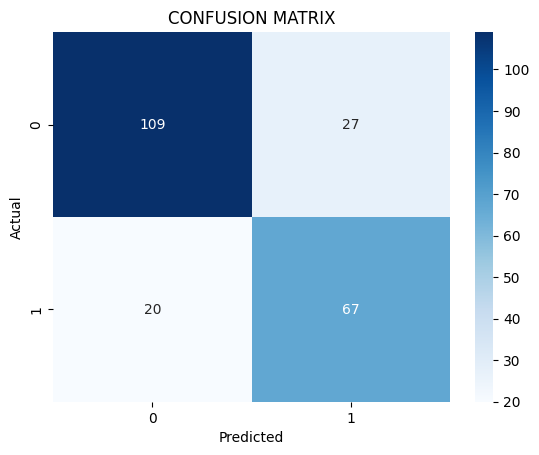

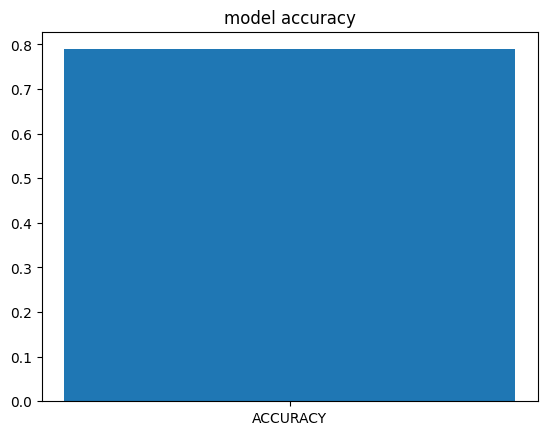

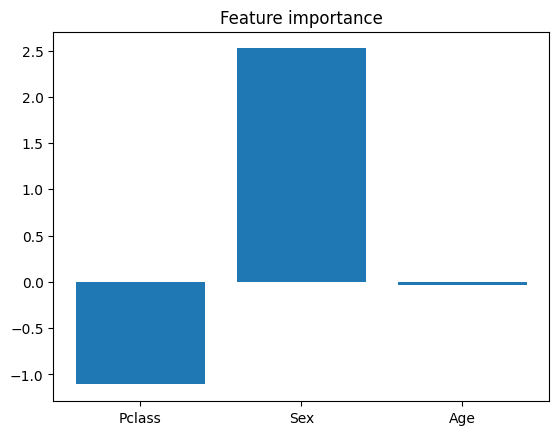

In [29]:
df=pd.read_csv("train.csv")
#SIMPLE CLEANING
df=df[['Survived','Pclass','Sex','Age']]
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Sex']=df['Sex'].map({'male':0,'female':1})

x=df[['Pclass','Sex','Age']]
y=df['Survived']
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
x_train,x_test,y_train,y_test=train_test_split(x,y)
#MODEL
model=LogisticRegression()
model.fit(x_train,y_train)
from sklearn.metrics import accuracy_score
#ACCURACY
print("Accuracy:",accuracy_score(y_test,model.predict(x_test)))
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)
#CONFUSION MATRIX GRAPH
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CONFUSION MATRIX")
plt.show()
#BAR GRAPH
accuracy=accuracy_score(y_test,y_pred)
plt.bar(["ACCURACY"],[accuracy])
plt.title("model accuracy")
plt.show()
#FEATURE IMPORTANCE
import pandas as pd
features=x.columns
importance=model.coef_[0]
plt.bar(features,importance)
plt.title("Feature importance")
plt.show()